In [1]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, img_as_float
from skimage.util import random_noise
from skimage.filters import gaussian
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.restoration import denoise_tv_chambolle
from scipy.ndimage import median_filter

In [2]:
image = img_as_float(data.camera())

In [3]:
noisy = random_noise(image, mode='gaussian', var=0.01)

In [6]:
gaussian_denoised = gaussian(noisy, sigma=1) #Gaussian filter
median_denoised = median_filter(noisy, size=3) #Median filter
sigma_est = np.mean(estimate_sigma(noisy)) #Non-local means
nlm_denoised = denoise_nl_means(
noisy,
h=1.15 * sigma_est,
fast_mode=True,
patch_size=5,
patch_distance=6
)
tv_denoised = denoise_tv_chambolle(noisy, weight=0.1)  #Total variation denoising

In [7]:
def mse(original, denoised):
 return np.mean((original - denoised) ** 2)

def psnr(original, denoised):
 mse_val = mse(original, denoised)
 return 10 * np.log10(1.0 / mse_val)

methods = {
"Gaussian Filter": gaussian_denoised,
"Median Filter": median_denoised,
"Non-Local Means": nlm_denoised,
"TV Denoising": tv_denoised
}

print("Performance Metrics")
print("-" * 40)

for name, img in methods.items():
  print(
   f"{name:18s} | "
   f"MSE = {mse(image, img):.5f} | "
   f"PSNR = {psnr(image, img):.2f} dB"
   )

Performance Metrics
----------------------------------------
Gaussian Filter    | MSE = 0.00192 | PSNR = 27.16 dB
Median Filter      | MSE = 0.00269 | PSNR = 25.70 dB
Non-Local Means    | MSE = 0.00142 | PSNR = 28.48 dB
TV Denoising       | MSE = 0.00148 | PSNR = 28.30 dB


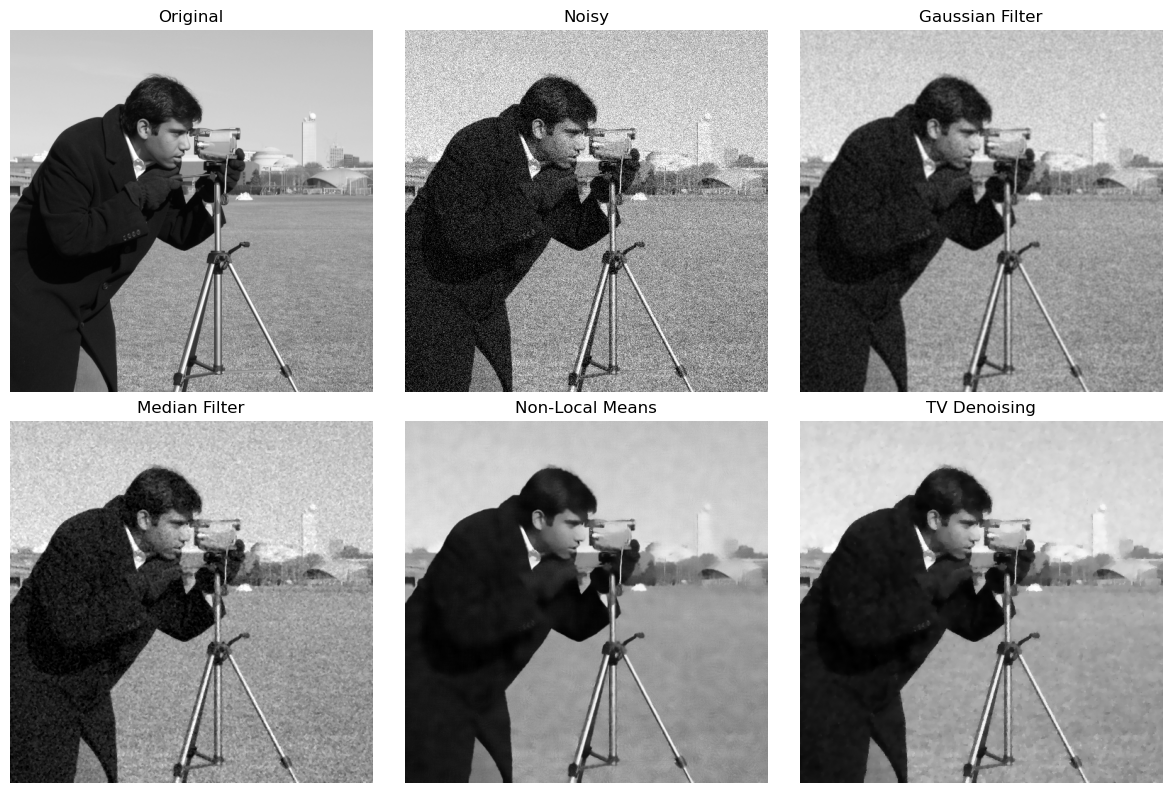

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12,8))

images = [
image,
noisy,
gaussian_denoised,
median_denoised,
nlm_denoised,
tv_denoised
]

titles = [
"Original",
"Noisy",
"Gaussian Filter",
"Median Filter",
"Non-Local Means",
"TV Denoising"
]

for ax, img, title in zip(axes.ravel(), images, titles):
  ax.imshow(img, cmap='gray')
  ax.set_title(title)
  ax.axis('off')

plt.tight_layout()
plt.show()